In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("01_anomaly_detection_obd2_readings.csv")

print(df.shape)
print(df.head())


(108372, 17)
             timestamp vehicle_id   engine_rpm  vehicle_speed_kmh  \
0  2025-01-01 00:14:00    VH-0001   619.372549           0.000000   
1  2025-01-01 01:04:00    VH-0001  2545.996132         129.457826   
2  2025-01-01 01:21:00    VH-0001   768.123823           0.000000   
3  2025-01-01 01:25:00    VH-0001  1388.936096          77.824961   
4  2025-01-01 01:50:00    VH-0001   679.907447           0.000000   

   coolant_temp_c  intake_air_temp_c  maf_airflow_gs  throttle_position_pct  \
0       87.449335          31.575631       12.772779               6.900739   
1       90.874553          26.927317       20.606743              44.323677   
2       87.911571          46.813269       17.100729               6.142695   
3       88.500717          38.554106       20.143098              27.116095   
4       91.571367          30.469618       15.298954               6.173714   

   fuel_level_pct  control_module_voltage_v  ambient_temp_c  \
0       44.308947                 

In [4]:
# supprimer colonnes inutiles
df = df.drop(columns=['timestamp', 'vehicle_id'], errors='ignore')

# supprimer valeurs manquantes
df = df.dropna()

In [5]:
features = [
    'engine_rpm',
    'vehicle_speed_kmh',
    'coolant_temp_c',
    'intake_air_temp_c',
    'maf_airflow_gs',
    'throttle_position_pct',
    'control_module_voltage_v',
    'engine_load_pct',
    'short_fuel_trim_pct',
    'long_fuel_trim_pct'
]

X = df[features]
y = df['is_anomaly'] 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X_train_scaled)

iso_pred = iso.predict(X_test_scaled)
iso_pred = (iso_pred == -1).astype(int)

In [24]:
svm = OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)

svm.fit(X_train_scaled)

svm_pred = svm.predict(X_test_scaled)
svm_pred = (svm_pred == -1).astype(int)

In [12]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

lof.fit(X_train_scaled)

lof_pred = lof.predict(X_test_scaled)
lof_pred = (lof_pred == -1).astype(int)

In [13]:
final_pred = (
    0.4 * iso_pred +
    0.4 * svm_pred +
    0.2 * lof_pred
) >= 0.5

final_pred = final_pred.astype(int)

In [14]:
print("=== Isolation Forest ===")
print(classification_report(y_test, iso_pred))

print("=== One-Class SVM ===")
print(classification_report(y_test, svm_pred))

print("=== LOF ===")
print(classification_report(y_test, lof_pred))

print("=== Ensemble Model ===")
print(classification_report(y_test, final_pred))

=== Isolation Forest ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     20836
           1       0.61      0.80      0.69       839

    accuracy                           0.97     21675
   macro avg       0.80      0.89      0.84     21675
weighted avg       0.98      0.97      0.97     21675

=== One-Class SVM ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     20836
           1       0.62      0.80      0.70       839

    accuracy                           0.97     21675
   macro avg       0.81      0.89      0.84     21675
weighted avg       0.98      0.97      0.98     21675

=== LOF ===
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     20836
           1       0.05      0.07      0.06       839

    accuracy                           0.92     21675
   macro avg       0.51      0.51      0.51     21675
weighted avg   

In [15]:
print("F1 Score:", f1_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))

F1 Score: 0.6612111292962357
Precision: 0.6096579476861167
Recall: 0.7222884386174017


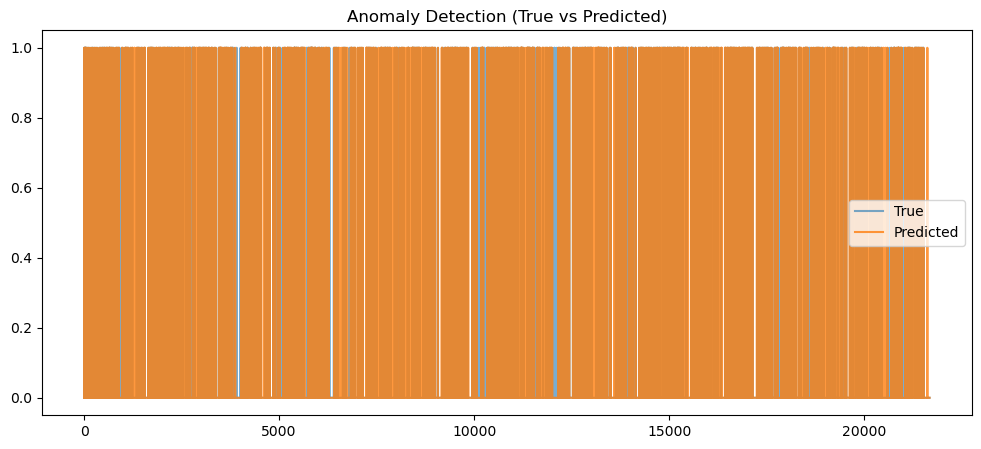

In [16]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="True", alpha=0.6)
plt.plot(final_pred, label="Predicted", alpha=0.8)

plt.legend()
plt.title("Anomaly Detection (True vs Predicted)")
plt.show()

In [26]:
print(confusion_matrix(y_test, iso_pred))
print(confusion_matrix(y_test, svm_pred))
print(confusion_matrix(y_test, lof_pred))
print(confusion_matrix(y_test, final_pred))

[[20405   431]
 [  164   675]]
[[20431   405]
 [  170   669]]
[[19784  1052]
 [  778    61]]
[[20448   388]
 [  233   606]]


In [34]:
joblib.dump(svm, "svm_model.pkl")
joblib.dump(iso, "iso_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']